# File

In [49]:
import pandas as pd
from sklearn.model_selection import train_test_split
df = pd.read_csv("TORUN.csv") # ETO YUNG GINAMIT KONG CSV YA CHINECK Q NA
X = df.drop('HIV_Status', axis=1)
y = df['HIV_Status']

# First, pull out 20% for the final unseen Test set
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=67
)

# Next, split the remaining 80% into Train (60%) and Validation (20%)
# 0.25 x 0.80 = 0.20
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, stratify=y_temp, test_size=0.25, random_state=67
)

In [50]:
df.head(10)

,Sex,Age_Group,Transmission,Healthcare_Access_Friction,Civil_Status,OFW_Status,Chemsex_Engagement,Alcohol_Sex_Risk,PrEP_Awareness,Transactional_Sex,STI_BBV_CoInfection_Any,HIV_Status
0,Female,<15,Male to Female Sex,2,Single,No,No,No,No,No TS,No,Reactive
1,Male,15-24,Male to Female Sex,2,Single,No,No,No,No,No TS,No,Reactive
2,Male,15-24,Male to Male Sex,2,Single,No,No,No,Yes,No TS,Yes,Reactive
3,Male,15-24,Male to Male Sex,2,Single,No,No,No,No,No TS,Yes,Reactive
4,Male,15-24,Male to Male Sex,2,Single,No,Yes,No,Yes,No TS,No,Reactive
5,Male,15-24,Male to Male/Female Sex,2,Single,No,No,Yes,Yes,Both,No,Reactive
6,Male,25-34,Male to Female Sex,2,Common-Law,No,No,No,No,No TS,No,Reactive
7,Male,25-34,Male to Male Sex,2,Single,No,No,No,Yes,No TS,No,Reactive
8,Male,25-34,Male to Male Sex,2,Single,No,No,No,No,No TS,No,Reactive
9,Male,25-34,Male to Male Sex,2,Single,No,No,Yes,Yes,Paid for sex,Yes,Reactive


# Preprocessing

In [51]:
from sklearn.preprocessing import OrdinalEncoder
import pandas as pd
import numpy as np

categorical_features = ['Sex','Age_Group','Transmission',
                        'Healthcare_Access_Friction','Civil_Status','OFW_Status','Chemsex_Engagement',
                        'Alcohol_Sex_Risk','PrEP_Awareness','Transactional_Sex','STI_BBV_CoInfection_Any']

# 1. Use OrdinalEncoder instead of OneHotEncoder
# This converts categories into integers (e.g., 0, 1, 2)
# Unknowns are temporarily flagged as -1
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

# Fit and transform
X_train_encoded = encoder.fit_transform(X_train[categorical_features])
X_val_encoded = encoder.transform(X_val[categorical_features])
X_test_encoded = encoder.transform(X_test[categorical_features])

# 2. Safely handle Unknowns & Extract Vocabulary Sizes
# The Neural Network needs to know exactly how many unique integers exist in each column
category_counts = {}
for i, col in enumerate(categorical_features):
    num_classes = len(encoder.categories_[i])
    
    # Replace the -1 (unseen categories) with a dedicated "Unknown" index (num_classes)
    X_train_encoded[:, i] = np.where(X_train_encoded[:, i] == -1, num_classes, X_train_encoded[:, i])
    X_val_encoded[:, i] = np.where(X_val_encoded[:, i] == -1, num_classes, X_val_encoded[:, i])
    X_test_encoded[:, i] = np.where(X_test_encoded[:, i] == -1, num_classes, X_test_encoded[:, i])
    
    # Total vocabulary size is original classes + 1 (for the "Unknown" bucket)
    category_counts[col] = num_classes + 1

# 3. Convert back to DataFrames
X_train_processed = pd.DataFrame(X_train_encoded, columns=categorical_features, index=X_train.index)
X_val_processed = pd.DataFrame(X_val_encoded, columns=categorical_features, index=X_val.index)
X_test_processed = pd.DataFrame(X_test_encoded, columns=categorical_features, index=X_test.index)

# Dealing with y columns (Unchanged)
mapping = {'Non-Reactive': 0, 'Reactive': 1}
y_train_processed = y_train.map(mapping)
y_val_processed = y_val.map(mapping)
y_test_processed = y_test.map(mapping)

# --- NEW CRITICAL STEP ---
# The Keras Functional API requires multiple inputs to be passed as a dictionary
X_train_dict = {col: X_train_processed[col].values for col in categorical_features}
X_val_dict = {col: X_val_processed[col].values for col in categorical_features}
X_test_dict = {col: X_test_processed[col].values for col in categorical_features}

 # MODEL

In [52]:
from tensorflow.keras.layers import Input, Embedding, Flatten, Concatenate, Dense, Dropout, BatchNormalization
import tensorflow as tf
import keras_tuner as kt

# Calculate Initial Output Bias (Unchanged)
neg_count = (y_train_processed == 0).sum()
pos_count = (y_train_processed == 1).sum()
initial_bias = np.log([pos_count / neg_count])
output_bias = tf.keras.initializers.Constant(initial_bias)

# Define the Model Builder using the Functional API
def build_embedding_model(hp):
    all_inputs = []
    all_embeddings = []

    # 1. Create an Input and Embedding layer for EVERY category
    for col_name, vocab_size in category_counts.items():
        # Define the entry point for this specific column
        input_layer = Input(shape=(1,), name=col_name)
        
        # Determine Embedding Size: Rule of thumb is min(50, vocab_size // 2)
        embed_dim = max(2, min(50, vocab_size // 2))
        
        # Create the Embedding
        embed_layer = Embedding(input_dim=vocab_size, output_dim=embed_dim)(input_layer)
        embed_layer = Flatten()(embed_layer)
        
        all_inputs.append(input_layer)
        all_embeddings.append(embed_layer)

    # 2. Merge all the embedding vectors together
    x = Concatenate()(all_embeddings)

    # 3. Add Dense Hidden Layers
    hp_neurons = hp.Int('neurons', min_value=64, max_value=256, step=64)
    hp_dropout_1 = hp.Float('dropout_1', min_value=0.3, max_value=0.5, step=0.1)
    hp_dropout_rest = hp.Float('dropout_rest', min_value=0.2, max_value=0.4, step=0.1)

    # First Hidden Layer
    x = Dense(hp_neurons, activation='swish')(x)
    x = BatchNormalization()(x)
    x = Dropout(hp_dropout_1)(x)

    # Dynamic Depth (Tuner decides 1 to 3 extra layers)
    for i in range(hp.Int('num_layers', 1, 3)):
        x = Dense(hp_neurons // (2**(i+1)), activation='swish')(x)
        x = BatchNormalization()(x)
        x = Dropout(hp_dropout_rest)(x)

    # 4. Final Output Layer
    output = Dense(1, activation='sigmoid', bias_initializer=output_bias)(x)

    # Combine Inputs and Outputs into the Model
    model = tf.keras.Model(inputs=all_inputs, outputs=output)

    # Compile
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-3, 5e-4, 1e-4])
    focal_loss = tf.keras.losses.BinaryFocalCrossentropy(
        gamma=2.0, alpha=0.25, label_smoothing=0.1, apply_class_balancing=True
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=hp_learning_rate),
        loss=focal_loss,
        metrics=[tf.keras.metrics.AUC(curve='PR', name='auprc')]
    )
    return model

In [53]:
# Initialize Tuner
tuner = kt.RandomSearch( 
    build_embedding_model, # <--- Updated function name
    objective=kt.Objective("val_auprc", direction="max"), 
    max_trials=10, 
    directory='nn_tuning_dir',
    project_name='reactive_embeddings',
    overwrite=True 
)

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
early_stop = EarlyStopping(monitor='val_auprc', mode='max', patience=8, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_auprc', factor=0.2, patience=3, min_lr=1e-6, mode='max', verbose=1)

print("Commencing Search with Embedding Architecture...")
tuner.search(
    X_train_dict, # <--- Passing the Dictionary!
    y_train_processed,
    epochs=50,
    batch_size=1024, 
    validation_data=(X_val_dict, y_val_processed), # <--- Passing the Dictionary!
    callbacks=[early_stop, reduce_lr],
    verbose=1
)


Trial 10 Complete [00h 00m 42s]
val_auprc: 0.1389016956090927

Best val_auprc So Far: 0.13983947038650513
Total elapsed time: 00h 05m 26s


In [54]:
# 4. Extract and Finalize
best_nn_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"\nBest Config: Layers: {best_nn_hps.get('num_layers')}, Neurons: {best_nn_hps.get('neurons')}")

best_nn_model = tuner.hypermodel.build(best_nn_hps)

# Final Training
best_nn_model.fit(
    X_train_dict,       # Changed from X_train_processed
    y_train_processed,
    epochs=100,
    batch_size=1024,
    validation_data=(X_val_dict, y_val_processed), # Changed from X_val_processed
    callbacks=[
        EarlyStopping(monitor='val_auprc', patience=12, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_auprc', factor=0.1, patience=4, mode='max', verbose=1)
    ],
    verbose=0
)

# 5. Evaluate and Find Optimal Threshold
from sklearn.metrics import (
    precision_recall_curve, 
    classification_report, 
    f1_score, 
    average_precision_score,
    confusion_matrix, 
    balanced_accuracy_score, 
    brier_score_loss
)
from sklearn.calibration import calibration_curve
import numpy as np

print("\nFinding Optimal Threshold on Validation Set...")
# Get probabilities for Validation Set
val_probs_nn = best_nn_model.predict(X_val_dict, batch_size=1024).ravel() 

# Calculate PR curve and F1 scores to find the exact threshold that maximizes F1
precisions, recalls, thresholds = precision_recall_curve(y_val_processed, val_probs_nn)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
best_threshold = thresholds[np.argmax(f1_scores[:-1])]

print(f"Optimal Operating Threshold: {best_threshold:.4f}")

# Predict on Test Set using the NEW threshold
y_probs_nn = best_nn_model.predict(X_test_dict, batch_size=1024).ravel() 

# 1. Calculate predictions using the new golden threshold
y_pred_nn_optimal = (y_probs_nn >= best_threshold).astype(int)

# 2. Calculate predictions using the standard 50% threshold
y_pred_nn_default = (y_probs_nn >= 0.5).astype(int)

# 3. Calculate Specificity (True Negative Rate)
tn, fp, fn, tp = confusion_matrix(y_test_processed, y_pred_nn_optimal).ravel()
specificity = tn / (tn + fp)

# 4. Calculate Balanced Accuracy
bal_acc = balanced_accuracy_score(y_test_processed, y_pred_nn_optimal)

# 5. Calculate Brier Score (Overall Calibration Metric)
brier_score = brier_score_loss(y_test_processed, y_probs_nn)

# 6. Optional: Generate data for a Calibration Curve (for plotting)
prob_true, prob_pred = calibration_curve(y_test_processed, y_probs_nn, n_bins=10)

print("\n--- Tuned Neural Network Final Report (Large Scale) ---")
print(classification_report(y_test_processed, y_pred_nn_optimal, target_names=['Non Reactive', 'Reactive']))

# Print both F1 scores so you can compare!
print(f"Default (50%) NN F1-Score:  {f1_score(y_test_processed, y_pred_nn_default):.4f}")
print(f"Optimal Tuned NN F1-Score:  {f1_score(y_test_processed, y_pred_nn_optimal):.4f}")
print(f"Tuned NN AUPRC:             {average_precision_score(y_test_processed, y_probs_nn):.4f}")

# --- NEW METRICS PRINT STATEMENTS ---
print(f"Specificity (TNR):          {specificity:.4f}")
print(f"Balanced Accuracy:          {bal_acc:.4f}")
print(f"Brier Score:                {brier_score:.4f}")

# Uncomment below if you want to inspect the raw calibration bins
# print(f"\nCalibration True Probs: {prob_true}")
# print(f"Calibration Pred Probs: {prob_pred}")


Best Config: Layers: 3, Neurons: 128

Epoch 41: ReduceLROnPlateau reducing learning rate to 5.0000002374872565e-05.

Epoch 45: ReduceLROnPlateau reducing learning rate to 5.000000237487257e-06.

Epoch 49: ReduceLROnPlateau reducing learning rate to 5.000000328436726e-07.

Finding Optimal Threshold on Validation Set...
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Optimal Operating Threshold: 0.2021
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

--- Tuned Neural Network Final Report (Large Scale) ---
              precision    recall  f1-score   support

Non Reactive       0.94      0.75      0.83     60291
    Reactive       0.13      0.47      0.21      4973

    accuracy                           0.72     65264
   macro avg       0.54      0.61      0.52     65264
weighted avg       0.88      0.72      0.79     65264

Default (50%) NN F1-Score:  0.0000
Optimal Tuned NN F1-Score:  0.2062
Tuned NN AUPRC:             0.1383
Specificity (TNR):          0.7459
Balanced Accuracy:          0.6075
Brier 

# Threshold Moving 

In [55]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    f1_score, 
    precision_score, 
    recall_score,
    precision_recall_curve,
    confusion_matrix,           
    balanced_accuracy_score,    
    brier_score_loss            
)

# ---------------------------------------------------------
# STEP 1: FIND THE GOLDEN THRESHOLD ON THE *VALIDATION* SET
# ---------------------------------------------------------

# Keras .predict() returns [[p1], [p2]...], so we flatten it to [p1, p2...]
# CRITICAL FIX: Use X_val_dict for the Embedding network inputs!
nn_probs_val = best_nn_model.predict(X_val_dict).flatten()

# Get all exact thresholds and their metrics instantly
precisions, recalls, thresholds = precision_recall_curve(y_val_processed, nn_probs_val)

# Calculate F1 scores mathematically (adding 1e-8 prevents division by zero)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)

# Find the "Golden Threshold"
# Note: precision_recall_curve returns one less threshold than precision/recall values
best_idx = np.argmax(f1_scores[:-1]) 
miku_threshold = thresholds[best_idx]

print(f"Golden Threshold (Found on Val Set): {miku_threshold:.4f}")

# ---------------------------------------------------------
# STEP 2: EVALUATE THIS THRESHOLD ON THE *TEST* SET
# ---------------------------------------------------------

# CRITICAL FIX: Use X_test_dict for the Embedding network inputs!
nn_probs_test = best_nn_model.predict(X_test_dict).flatten()

# Apply the golden threshold vs standard 0.5
optimal_preds_test = (nn_probs_test >= miku_threshold).astype(int)
default_preds_test = (nn_probs_test >= 0.5).astype(int)

# --- CALCULATE NEW METRICS FOR BOTH ---

# 1. Specificity (How well we identify 'Non-Reactive')
tn_opt, fp_opt, fn_opt, tp_opt = confusion_matrix(y_test_processed, optimal_preds_test).ravel()
specificity_optimal = tn_opt / (tn_opt + fp_opt)

tn_def, fp_def, fn_def, tp_def = confusion_matrix(y_test_processed, default_preds_test).ravel()
specificity_default = tn_def / (tn_def + fp_def)

# 2. Balanced Accuracy (Average of Recall and Specificity)
bal_acc_optimal = balanced_accuracy_score(y_test_processed, optimal_preds_test)
bal_acc_default = balanced_accuracy_score(y_test_processed, default_preds_test)

# 3. Brier Score (Static across thresholds, calculated on probabilities)
brier_test = brier_score_loss(y_test_processed, nn_probs_test)


# ---------------------------------------------------------
# PRINT THE FINAL COMPARISON
# ---------------------------------------------------------
print("\n--- FINAL TEST SET PERFORMANCE COMPARISON ---")
print(f"{'Metric':<20} | {'Default (0.5)':<15} | {'Optimized ('+str(round(miku_threshold,2))+')':<15}")
print("-" * 60)
print(f"{'F1-Score':<20} | {f1_score(y_test_processed, default_preds_test):<15.4f} | {f1_score(y_test_processed, optimal_preds_test):<15.4f}")
print(f"{'Precision':<20} | {precision_score(y_test_processed, default_preds_test, zero_division=0):<15.4f} | {precision_score(y_test_processed, optimal_preds_test, zero_division=0):<15.4f}")
print(f"{'Recall':<20} | {recall_score(y_test_processed, default_preds_test):<15.4f} | {recall_score(y_test_processed, optimal_preds_test):<15.4f}")
print(f"{'Specificity':<20} | {specificity_default:<15.4f} | {specificity_optimal:<15.4f}")
print(f"{'Balanced Accuracy':<20} | {bal_acc_default:<15.4f} | {bal_acc_optimal:<15.4f}")
print("-" * 60)
print(f"Overall Brier Score (Calibration): {brier_test:.4f}")

2040/2040 ━━━━━━━━━━━━━━━━━━━━ 1s 501us/step
Golden Threshold (Found on Val Set): 0.2021
2040/2040 ━━━━━━━━━━━━━━━━━━━━ 1s 488us/step

--- FINAL TEST SET PERFORMANCE COMPARISON ---
Metric               | Default (0.5)   | Optimized (0.2)
------------------------------------------------------------
F1-Score             | 0.0000          | 0.2062         
Precision            | 0.0000          | 0.1321         
Recall               | 0.0000          | 0.4691         
Specificity          | 1.0000          | 0.7459         
Balanced Accuracy    | 0.5000          | 0.6075         
------------------------------------------------------------
Overall Brier Score (Calibration): 0.0816


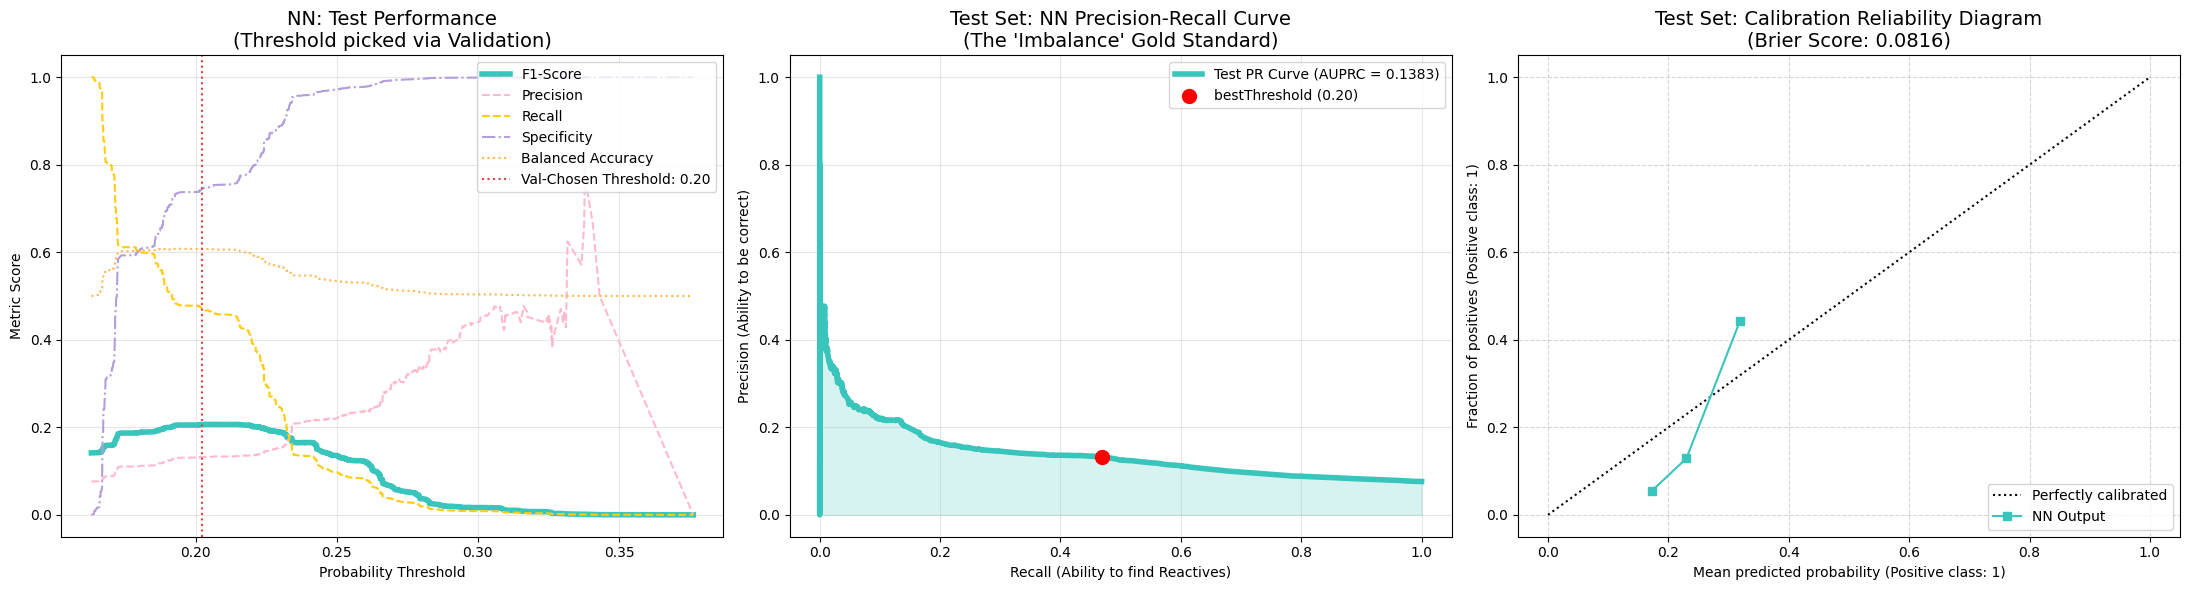

In [58]:

import matplotlib.pyplot as plt

# ---------------------------------------------------------
# STEP 3: PREPARE PLOTTING METRICS (ON TEST SET)
# ---------------------------------------------------------
precision_nn, recall_nn, pr_thresholds_nn = precision_recall_curve(y_test_processed, nn_probs_test)
test_f1s = 2 * (precision_nn * recall_nn) / (precision_nn + recall_nn + 1e-8)
auprc_nn = average_precision_score(y_test_processed, nn_probs_test)

# Calculate Specificity and Balanced Accuracy across all thresholds for Plot 1
test_specificity = []
test_bal_acc = []

for t in pr_thresholds_nn:
    preds = (nn_probs_test >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test_processed, preds).ravel()
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0 
    
    test_specificity.append(spec)
    test_bal_acc.append((spec + sens) / 2)

# ---------------------------------------------------------
# STEP 4: PLOT ALL 3 GRAPHS (1x3 GRID)
# ---------------------------------------------------------
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(22, 6))

# --- PLOT 1: Threshold vs Metrics (Calculated on Test Set) ---
ax1.plot(pr_thresholds_nn, test_f1s[:-1], label='F1-Score', color='#39C5BB', linewidth=4)
ax1.plot(pr_thresholds_nn, precision_nn[:-1], label='Precision', color='#FFBACC', linestyle='--')
ax1.plot(pr_thresholds_nn, recall_nn[:-1], label='Recall', color='#FFCC11', linestyle='--')
ax1.plot(pr_thresholds_nn, test_specificity, label='Specificity', color='#B39DDB', linestyle='-.')
ax1.plot(pr_thresholds_nn, test_bal_acc, label='Balanced Accuracy', color='#FFB74D', linestyle=':')

# The "Audit" Line marking the golden threshold found via Validation
ax1.axvline(miku_threshold, color='#DD4444', linestyle=':', 
            label=f'Val-Chosen Threshold: {miku_threshold:.2f}')

ax1.set_title("NN: Test Performance\n(Threshold picked via Validation)", fontsize=14)
ax1.set_xlabel("Probability Threshold")
ax1.set_ylabel("Metric Score")
ax1.legend()
ax1.grid(alpha=0.3)

# --- PLOT 2: Precision-Recall Curve ---
ax2.plot(recall_nn, precision_nn, color='#39C5BB', linewidth=4, label=f'Test PR Curve (AUPRC = {auprc_nn:.4f})')
ax2.fill_between(recall_nn, 0, precision_nn, color='#39C5BB', alpha=0.2)

# Mark where the VALIDATION threshold falls on the TEST curve
idx_nn = np.argmin(np.abs(pr_thresholds_nn - miku_threshold))
ax2.scatter(recall_nn[idx_nn], precision_nn[idx_nn], color='red', s=100, zorder=5, label=f'Actual Operating Point ({miku_threshold:.2f})')

ax2.set_title("Test Set: NN Precision-Recall Curve\n(The 'Imbalance' Gold Standard)", fontsize=14)
ax2.set_xlabel("Recall (Ability to find Reactives)")
ax2.set_ylabel("Precision (Ability to be correct)")
ax2.legend()
ax2.grid(alpha=0.3)

# --- PLOT 3: Calibration Curve ---
CalibrationDisplay.from_predictions(
    y_test_processed, 
    nn_probs_test, 
    n_bins=10, 
    name="NN Output",
    ax=ax3,
    color='#39C5BB'
)
ax3.set_title(f"Test Set: Calibration Reliability Diagram\n(Brier Score: {brier_test:.4f})", fontsize=14)
ax3.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# SHAP

Initializing Kernel Explainer...
Calculating SHAP values (this will show a progress bar)...


  0%|          | 0/500 [00:00<?, ?it/s]

/var/folders/n7/5_69qws5077gwwg97fhrzrm40000gn/T/ipykernel_5077/353764508.py:58: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_matrix_nn, test_df_sample, plot_type="bar")


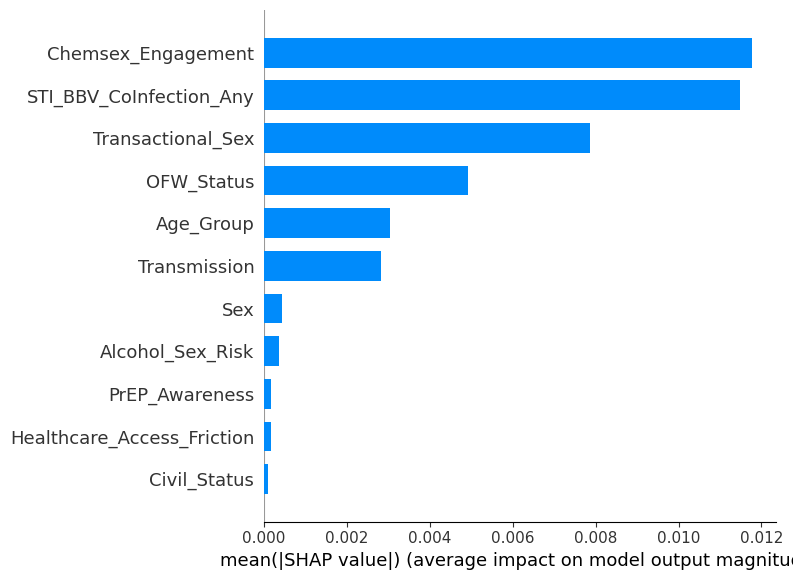

In [26]:
import shap
import numpy as np
import pandas as pd

# 1. Define the input names exactly as they are in your dictionary
input_names = list(X_train_dict.keys())

SAMPLE_SIZE = 200

# ---------------------------------------------------------
# STEP 1: THE TRANSLATOR FUNCTION
# ---------------------------------------------------------
def nn_predict_wrapper(X_matrix):
    """ 
    SHAP will pass a 2D numpy array here. 
    This function rebuilds the dictionary Keras needs, asks for predictions, 
    and returns a flattened 1D array of probabilities.
    """
    X_dict = {
        name: X_matrix[:, i] for i, name in enumerate(input_names)
    }
    return best_nn_model.predict(X_dict, verbose=0).flatten()

# ---------------------------------------------------------
# STEP 2: PREPARE THE DATA MATRICES
# ---------------------------------------------------------
# Because of our wrapper, we can go back to using simple 2D arrays!
background_matrix = X_train_processed[input_names].sample(n=100, random_state=42).values
test_matrix = X_test_processed[input_names].iloc[:SAMPLE_SIZE].values

# ---------------------------------------------------------
# STEP 3: INITIALIZE KERNEL EXPLAINER
# ---------------------------------------------------------
print("Initializing Kernel Explainer...")
# We pass our wrapper function instead of the raw model
explainer_nn = shap.KernelExplainer(nn_predict_wrapper, background_matrix)

# ---------------------------------------------------------
# STEP 4: CALCULATE SHAP VALUES
# ---------------------------------------------------------
print("Calculating SHAP values...")
shap_vals_nn = explainer_nn.shap_values(test_matrix)

# ---------------------------------------------------------
# STEP 5: FORMAT AND VISUALIZE
# ---------------------------------------------------------
# Handle potential list nesting based on your specific SHAP version
if isinstance(shap_vals_nn, list):
    shap_matrix_nn = shap_vals_nn[0]
else:
    shap_matrix_nn = shap_vals_nn

# Re-attach the column names to a DataFrame for the plot labels
test_df_sample = X_test_processed[input_names].iloc[:SAMPLE_SIZE]

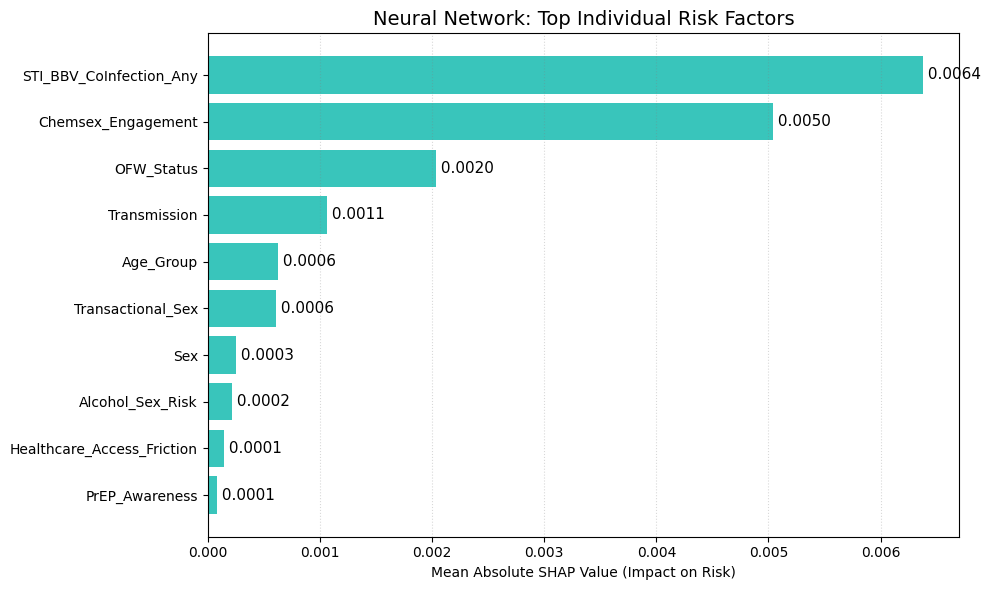

In [60]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Calculate the Mean Absolute SHAP value for every single unpacked column
mean_shap_values = np.abs(expanded_shap_df.values).mean(axis=0)

# 2. Match them to your specific column names
shap_importance = pd.DataFrame({
    'Feature': expanded_shap_df.columns,
    'Importance': mean_shap_values
})

# 3. Sort and isolate exactly the Top 10
top_10_features = shap_importance.sort_values(by='Importance', ascending=False).head(10)

# 4. Draw a clean, customized Bar Chart (No SHAP-specific plot functions)
plt.figure(figsize=(10, 6))

# We reverse the order ([::-1]) so the biggest bar is at the top
bars = plt.barh(top_10_features['Feature'][::-1], top_10_features['Importance'][::-1], color="#39C5BB")

plt.title("Neural Network: Top Individual Risk Factors", fontsize=14)
plt.xlabel("Mean Absolute SHAP Value (Impact on Risk)")

# 5. Add the exact numbers directly onto the bars
for bar in bars:
    plt.text(bar.get_width(), bar.get_y() + bar.get_height()/2, 
             f' {bar.get_width():.4f}', 
             va='center', ha='left', fontsize=11)

plt.grid(axis='x', color='gray', alpha=0.3, linestyle=':')
plt.tight_layout()
plt.show()

## Beeswarm

/var/folders/n7/5_69qws5077gwwg97fhrzrm40000gn/T/ipykernel_5077/3402512091.py:8: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


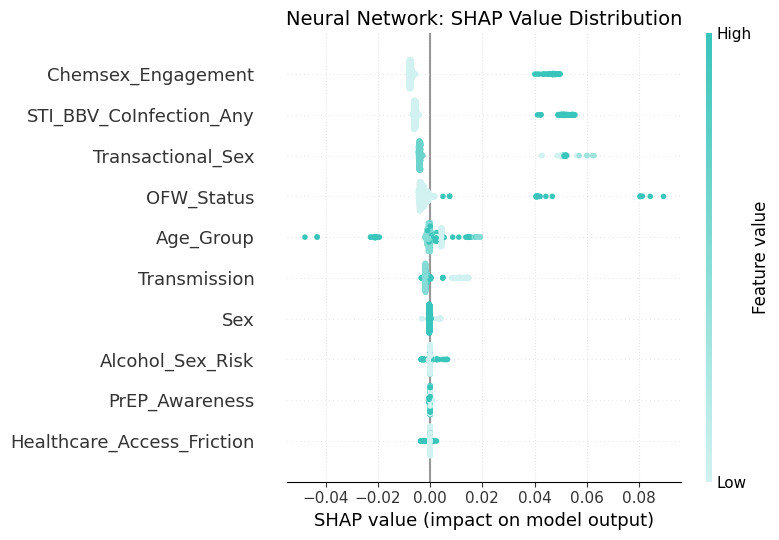

In [35]:
import matplotlib.colors as mcolors

plt.figure(figsize=(10, 6))
plt.title("Neural Network: SHAP Value Distribution", fontsize=14)

miku_cmap = mcolors.LinearSegmentedColormap.from_list("miku_gradient", ["#D1F2F0", "#39C5BB"])

shap.summary_plot(
    shap_matrix_nn,                      
    features=test_df_sample,             
    feature_names=test_df_sample.columns,
    plot_type="dot",
    cmap=miku_cmap,
    max_display=10,
    show=False
)

plt.grid(axis='x', color='gray', alpha=0.2, linestyle=':')
plt.tight_layout()
plt.show()

# SAVING THE MODEL (RUN MO TO YA IF YOU THINK MAGANDA RESULT PARA MASAVE)

In [59]:
import json
import joblib

print("Saving Neural Network artifacts...")

# 1. Save the Keras model natively (modern .keras format)
best_nn_model.save("best_nn_model.keras")
print("✓ Neural Network model saved as 'best_nn_model.keras'")

# 2. Save the optimal threshold into a small config file
nn_threshold_config = {"best_threshold": float(best_threshold)}
with open("nn_threshold_config.json", "w") as f:
    json.dump(nn_threshold_config, f)
print("✓ Optimal threshold saved as 'nn_threshold_config.json'")

# 3. Save the OrdinalEncoder (If you haven't already saved it during the XGBoost step!)
# joblib.dump(encoder, "ordinal_encoder.joblib")
# print("✓ Ordinal Encoder saved as 'ordinal_encoder.joblib'")

print("All artifacts saved successfully!")

Saving Neural Network artifacts...
✓ Neural Network model saved as 'best_nn_model.keras'
✓ Optimal threshold saved as 'nn_threshold_config.json'
All artifacts saved successfully!


# RELOADING

In [ ]:
import json
import joblib
import pandas as pd
import tensorflow as tf

print("Loading Neural Network artifacts...")

# 1. Load the Preprocessor (OrdinalEncoder)
loaded_encoder = joblib.load("ordinal_encoder.joblib")

# 2. Load the Threshold
with open("nn_threshold_config.json", "r") as f:
    loaded_config = json.load(f)
loaded_nn_threshold = loaded_config["best_threshold"]

# 3. Load the Keras Model
loaded_nn_model = tf.keras.models.load_model("best_nn_model.keras")

print(f"✓ Everything loaded! Operating Threshold: {loaded_nn_threshold:.4f}")

# ==========================================
# HOW TO PREDICT ON BRAND NEW DATA
# ==========================================
# Assuming 'new_patient_data' is a pandas DataFrame with raw string categories
# categorical_features = ['Sex', 'Age_Group', 'Transmission', ...] # (List your cols here)

# A. Transform strings to integers using the loaded encoder
# new_data_encoded = loaded_encoder.transform(new_patient_data[categorical_features])
# new_data_df = pd.DataFrame(new_data_encoded, columns=categorical_features)

# B. CRITICAL: Convert the flat dataframe into a Dictionary of arrays!
# (Because your model has an Input() layer for each column)
# new_data_dict = {col: new_data_df[col].values for col in categorical_features}

# C. Get Probabilities
# new_nn_probs = loaded_nn_model.predict(new_data_dict).ravel()

# D. Apply the Golden Threshold!
# final_nn_predictions = (new_nn_probs >= loaded_nn_threshold).astype(int)